In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

In [2]:
deliquent_dataset= pd.read_excel("C:/Users/MY-PC/data science/datasets/qvi/Delinquency_prediction_dataset.xlsx")

In [3]:
df = deliquent_dataset.copy()

In [4]:
df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [5]:
df.shape

(500, 19)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [8]:
null_df = pd.DataFrame( df.isnull().sum(),columns = ['total_null'])
null_df['null_percent'] = null_df['total_null']/df.shape[0]*100
null_df[null_df['total_null'] != 0]

,total_null,null_percent
Income,39,7.8
Credit_Score,2,0.4
Loan_Balance,29,5.8


In [9]:
df.describe()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.000000,461.000000,498.000000,500.000000,500.000000,500.000000,471.000000,500.000000,500.000000
mean,46.266000,108379.893709,577.716867,0.491446,2.968000,0.160000,48654.428875,0.298862,9.740000
std,16.187629,53662.723741,168.881211,0.197103,1.946935,0.366973,29395.537273,0.094521,5.923054
min,18.000000,15404.000000,301.000000,0.050000,0.000000,0.000000,612.000000,0.100000,0.000000
25%,33.000000,62295.000000,418.250000,0.356486,1.000000,0.000000,23716.500000,0.233639,5.000000
50%,46.500000,107658.000000,586.000000,0.485636,3.000000,0.000000,45776.000000,0.301634,10.000000
75%,59.250000,155734.000000,727.250000,0.634440,5.000000,0.000000,75546.500000,0.362737,15.000000
max,74.000000,199943.000000,847.000000,1.025843,6.000000,1.000000,99620.000000,0.552956,19.000000


In [10]:
df['Delinquent_Account'].value_counts()/df.shape[0]*100

Delinquent_Account
0    84.0
1    16.0
Name: count, dtype: float64

In [11]:
df['Employment_Status'].value_counts()

Employment_Status
Unemployed       93
retired          87
Employed         82
EMP              81
Self-employed    80
employed         77
Name: count, dtype: int64

In [12]:
df['Credit_Card_Type'].value_counts()

Credit_Card_Type
Gold        118
Student     112
Business    108
Standard     86
Platinum     76
Name: count, dtype: int64

In [13]:
df['Location'].value_counts()

Location
Los Angeles    107
Phoenix        103
Chicago        103
Houston         95
New York        92
Name: count, dtype: int64

## Inconsistent Data
- Income contains 39 missing values (~7.8% of records), which may reduce model accuracy if not handled properly.
- Loan_Balance has 29 missing values (~5.8%).
- Credit_Score has 2 missing values.
- Credit_Utilization includes values greater than 1.0 (100%), which may indicate data entry errors or unrealistic utilization ratios.
- Employment_Status field is inconsistent EMP, employed, Emlpoyed are same but appearing unique values
- Categorical fields such as Location, Credit_Card_Type, and monthly payment status columns appear consistent with no major missing values.
- There is no duplicate rows

## Key Anomalies
- A few customers show Credit_Utilization above 100%, which is unusual and should be validated before modeling.
- The target variable Delinquent_Account is imbalanced:
- Approximately 84% non-delinquent
- Approximately 16% delinquent
- Class imbalance may cause predictive models to favor the majority class unless balancing techniques are applied.
- Some customers have Account_Tenure = 0, which may represent newly opened accounts or incomplete records.

## Top 4 Variables Likely to Predict Delinquency
### `Delinquent_Account`
- Most important column for  help to understand the behavior and key characteristics of deliquent customers
### `Credit_Utilization`
- High utilization often reflects financial stress and overuse of available credit.
- Customers near or above their credit limits are more likely to default.
### `Credit_Score`
- Credit score is a strong indicator of historical repayment behavior and financial reliability.
- Lower scores are commonly associated with higher delinquency risk.
### `Debt_to_Income_Ratio`
- A high debt-to-income ratio suggests a customer’s income may not sufficiently cover existing debt obligations.
- This can increase the probability of missed payments and delinquency.

In [14]:
df['Employment_Status'].value_counts()

Employment_Status
Unemployed       93
retired          87
Employed         82
EMP              81
Self-employed    80
employed         77
Name: count, dtype: int64

In [15]:
# fixing data incoosistencies  in  Employment_Status column
df['Employment_Status'] = df['Employment_Status'].str.strip().str.title()
# replacing Emp with Employed
df['Employment_Status'] = df['Employment_Status'].replace({'Emp':'Employed','Self-Employed':'Employed'})
# replacing Self-employed with Employed


In [16]:
df['Employment_Status'].value_counts()

Employment_Status
Employed      320
Unemployed     93
Retired        87
Name: count, dtype: int64

## handling missing values in Income column


In [17]:
df['Income'].skew()

np.float64(0.0460865090566657)

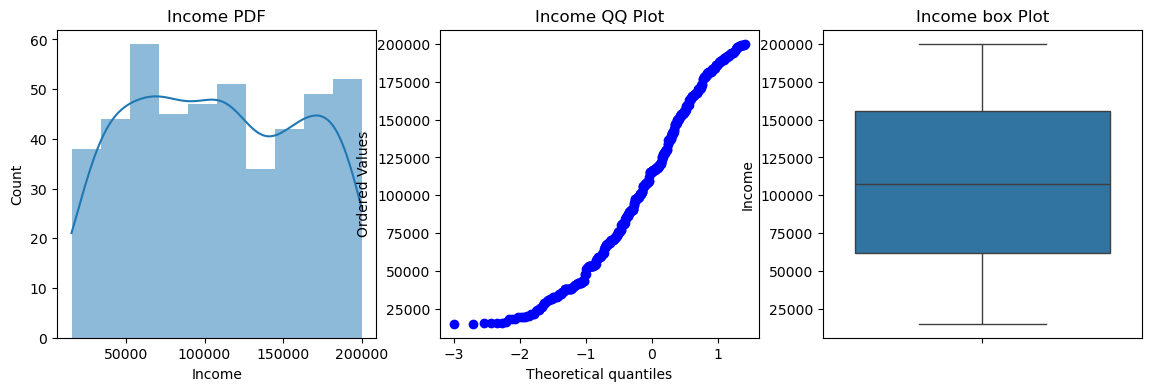

In [18]:
plt.figure(figsize=(14,4))
plt.subplot(131)
sns.histplot(df['Income'],kde =True,linewidth = 0)
plt.title('Income PDF')

plt.subplot(132)
stats.probplot(df['Income'], dist="norm", plot=plt)
plt.title('Income QQ Plot')

plt.subplot(133)
sns.boxplot(y = df['Income'])
plt.title('Income box Plot')

plt.show()

- as the data is approximately normal on qq plot and no outlier detection but skew of the data is 0.04. based on the plots mean method will be used for filling missing values in income

In [19]:
income_dict = round(df.groupby(['Employment_Status'])['Income'].mean(),1).to_dict()
df['Income'] = df['Income'].fillna(df['Employment_Status'].map(income_dict))

## handling missing values in Credit_Score column

In [20]:
df['Credit_Score'].skew()

np.float64(-0.03405560813525009)

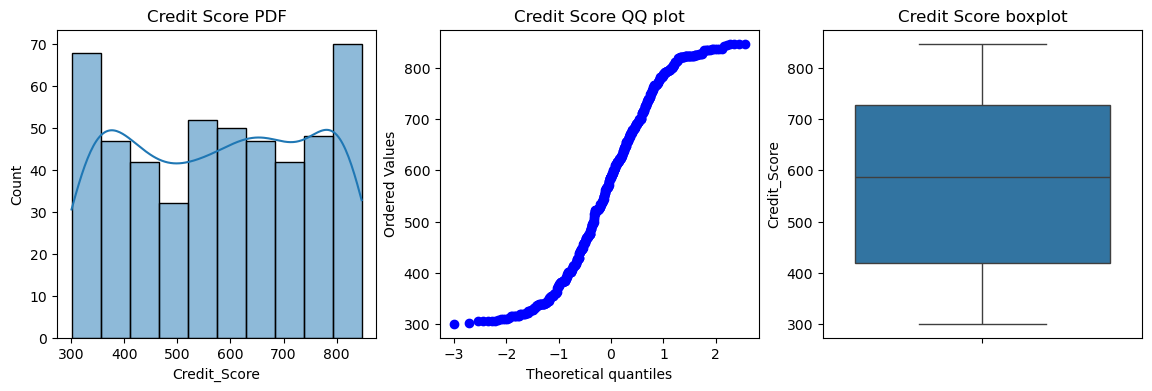

In [21]:
plt.figure(figsize = (14,4))

plt.subplot(131)
sns.histplot(x = df['Credit_Score'], kde = True)
plt.title('Credit Score PDF')

plt.subplot(132)
stats.probplot(x = df['Credit_Score'], dist  = 'norm' , plot = plt)
plt.title('Credit Score QQ plot')

plt.subplot(133)
sns.boxplot(y = df['Credit_Score'])
plt.title('Credit Score boxplot')

plt.show()

- as the data is approximately normal on qq plot and no outlier detection but skew of the data is 0.04. based on the plots mean method will be used for filling missing values in income

In [22]:
credit_dict = round(df.groupby(['Employment_Status'])['Credit_Score'].mean()).to_dict()
df['Credit_Score'] = df['Credit_Score'].fillna(df['Employment_Status'].map(credit_dict))
credit_dict

{'Employed': 579.0, 'Retired': 571.0, 'Unemployed': 579.0}

## handling missing values in Loan_Balance column

In [23]:
df['Loan_Balance'].skew()

np.float64(0.1051966422322644)

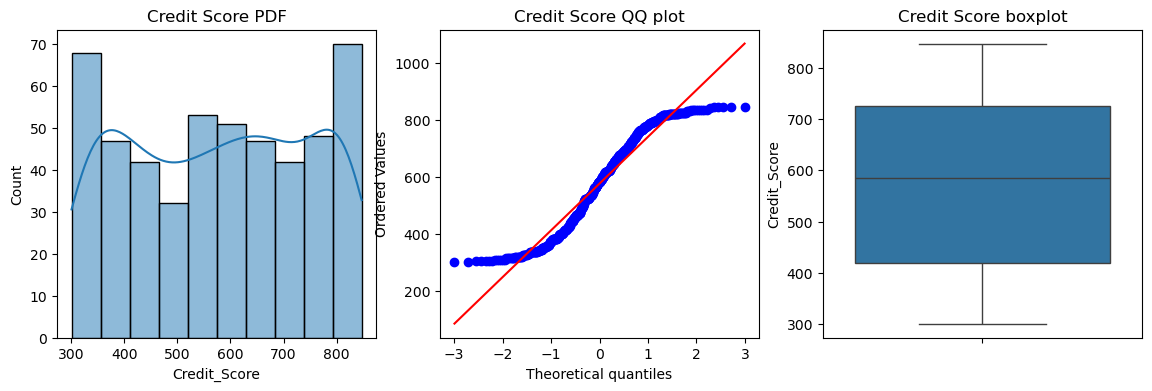

In [24]:
plt.figure(figsize = (14,4))

plt.subplot(131)
sns.histplot(x = df['Credit_Score'], kde = True)
plt.title('Credit Score PDF')

plt.subplot(132)
stats.probplot(x = df['Credit_Score'], dist  = 'norm' , plot = plt)
plt.title('Credit Score QQ plot')

plt.subplot(133)
sns.boxplot(y = df['Credit_Score'])
plt.title('Credit Score boxplot')

plt.show()

### using median method to fill missing values. As hist plot  qq plot  is not perfectly normal and skew is 0.1 

In [25]:
loan_dict = round(df.groupby(['Employment_Status'])['Loan_Balance'].median()).to_dict()
df['Loan_Balance'] = df['Loan_Balance'].fillna(df['Employment_Status'].map(loan_dict))
loan_dict

{'Employed': 44454.0, 'Retired': 52217.0, 'Unemployed': 44454.0}

## handling Credit_Utilization includes values greater than 1.0 (100%)

In [26]:
df[df['Credit_Utilization'] > 1]

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
89,CUST0090,65,127856.0,361.0,1.025843,2,0,2200.0,0.346267,Employed,14,Standard,Chicago,On-time,Late,On-time,Missed,Missed,On-time
265,CUST0266,72,16062.0,584.0,1.025017,1,0,92285.0,0.240017,Unemployed,17,Gold,Phoenix,Missed,Late,Missed,Missed,On-time,Late
292,CUST0293,49,38061.0,316.0,1.002482,1,0,95267.0,0.448824,Employed,16,Student,Chicago,Late,Late,Late,Late,Missed,Missed
426,CUST0427,49,163216.0,768.0,1.008734,6,0,60530.0,0.452937,Employed,15,Gold,New York,Late,On-time,Missed,Late,Late,Missed


In [27]:
# clipping to 1
df['Credit_Utilization'] = df['Credit_Utilization'].clip(upper = 1)

The dataset contained moderate missing values and a few inconsistent financial records. Median imputation was used to handle missing numerical data, while categorical inconsistencies were standardized. Unrealistic credit utilization values were corrected to improve reliability. Overall, the dataset became cleaner and more suitable for delinquency prediction modeling

In [28]:
df.isnull().sum()

Customer_ID             0
Age                     0
Income                  0
Credit_Score            0
Credit_Utilization      0
Missed_Payments         0
Delinquent_Account      0
Loan_Balance            0
Debt_to_Income_Ratio    0
Employment_Status       0
Account_Tenure          0
Credit_Card_Type        0
Location                0
Month_1                 0
Month_2                 0
Month_3                 0
Month_4                 0
Month_5                 0
Month_6                 0
dtype: int64

# Creating Columns
- creating age group based on age column
- creating credit score classification based on credit score

In [29]:
labels = ['Young', 'Middle-Aged','Senior']
df['Age_Demographics'] = pd.qcut(df['Age'],q =   3,labels = labels)

In [30]:
df.groupby('Age_Demographics').agg({'Age':['mean','min','max']})

C:\Users\MY-PC\AppData\Local\Temp\ipykernel_8536\2399085933.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Demographics').agg({'Age':['mean','min','max']})


Age        
                       mean min max
Age_Demographics                   
Young             28.034286  18  39
Middle-Aged       47.156250  40  55
Senior            64.739394  56  74

In [31]:
bins = [300,551,651,751,900]
labels = ['Poor','Average','Good','Excellent']
df['credit_score_rating'] = pd.cut(df['Credit_Score'],bins = bins,labels = labels)

In [32]:
df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,...,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Age_Demographics,credit_score_rating
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,Employed,...,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late,Senior,Poor
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Employed,...,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time,Senior,Poor
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Employed,...,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late,Middle-Aged,Poor
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,...,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late,Young,Poor
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Employed,...,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late,Senior,Poor


## univariate analysis

In [33]:
df.columns

Index(['Customer_ID', 'Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Delinquent_Account', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure',
       'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3',
       'Month_4', 'Month_5', 'Month_6', 'Age_Demographics',
       'credit_score_rating'],
      dtype='object')

In [34]:

num_cols = ['Age', 'Income', 'Credit_Score', 'Credit_Utilization','Missed_Payments','Loan_Balance',	'Debt_to_Income_Ratio','Account_Tenure']
cat_cols = ['Missed_Payments','Delinquent_Account','Employment_Status','Account_Tenure',
       'Credit_Card_Type','Location', 'Month_1', 'Month_2', 'Month_3',
       'Month_4', 'Month_5', 'Month_6', 'Age_Demographics',
       'credit_score_rating']

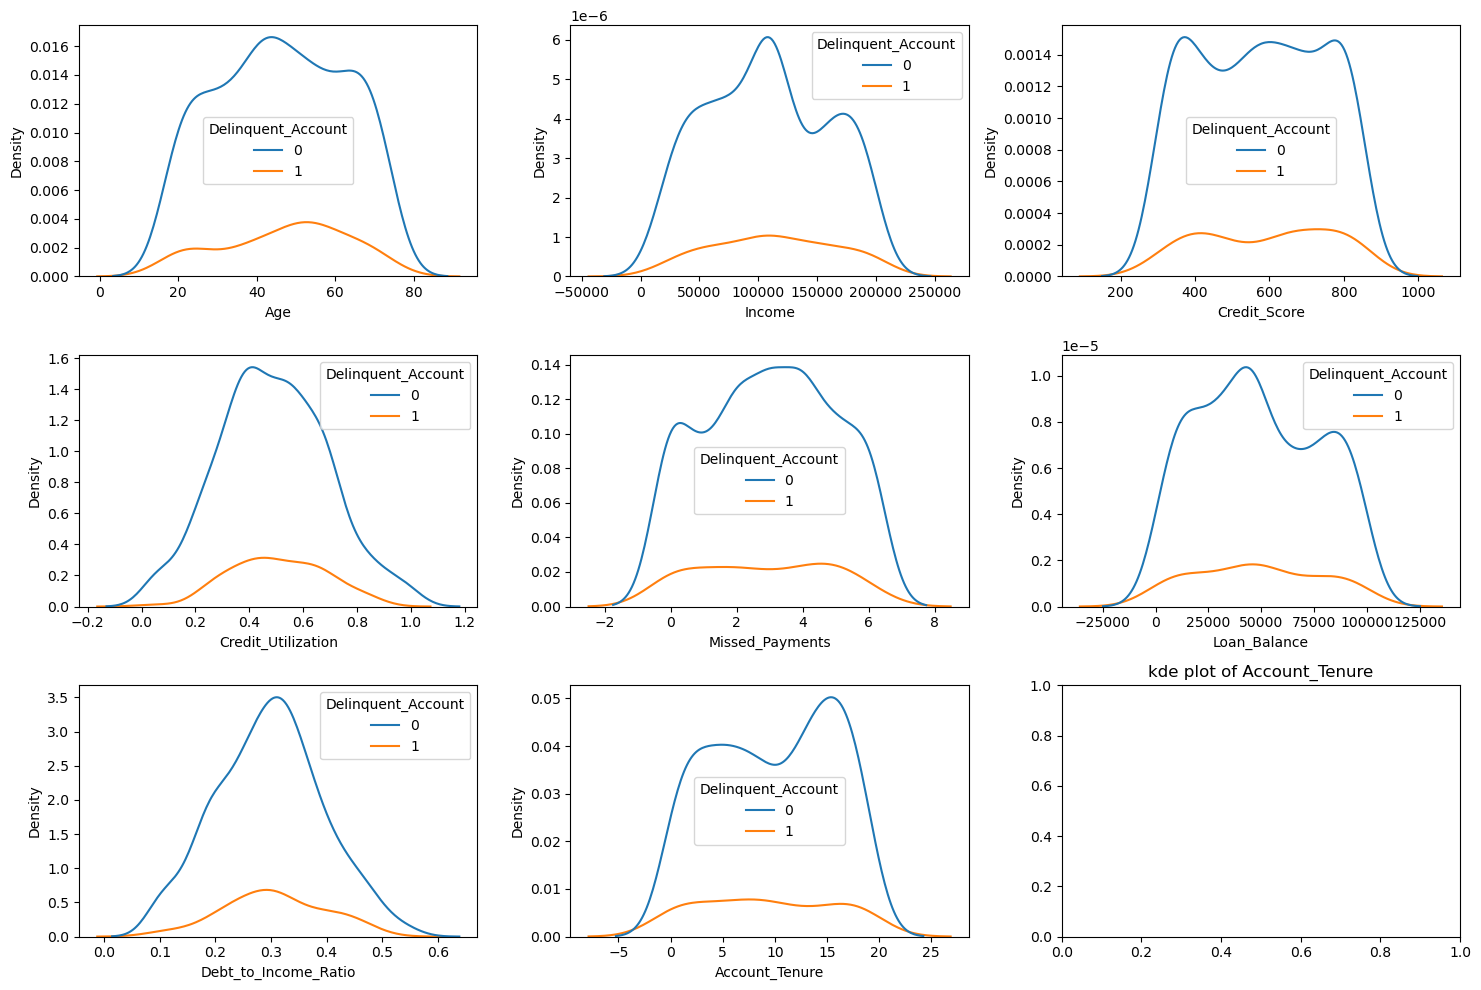

In [35]:

fig,ax = plt.subplots(3,3,figsize = (15,10),)
ax = ax.flatten()
for i,col in enumerate(num_cols):
    sns.kdeplot(data =df , x = col,ax =ax[i],hue = 'Delinquent_Account')
    plt.title(f'kde plot of {col}')

plt.tight_layout()
plt.show()

## Insights 
- The univariate analysis shows that most numerical variables are fairly well distributed without extreme skewness.
- Age is mainly concentrated between 30–60 years, indicating that middle-aged customers form the majority of the dataset.
- Credit utilization and debt-to-income ratio appear approximately normally distributed, suggesting that most customers maintain moderate credit usage and manageable debt levels.
- Credit scores are spread across a wide range, which indicates the presence of both low-risk and high-risk customers in the financial delinquency dataset.


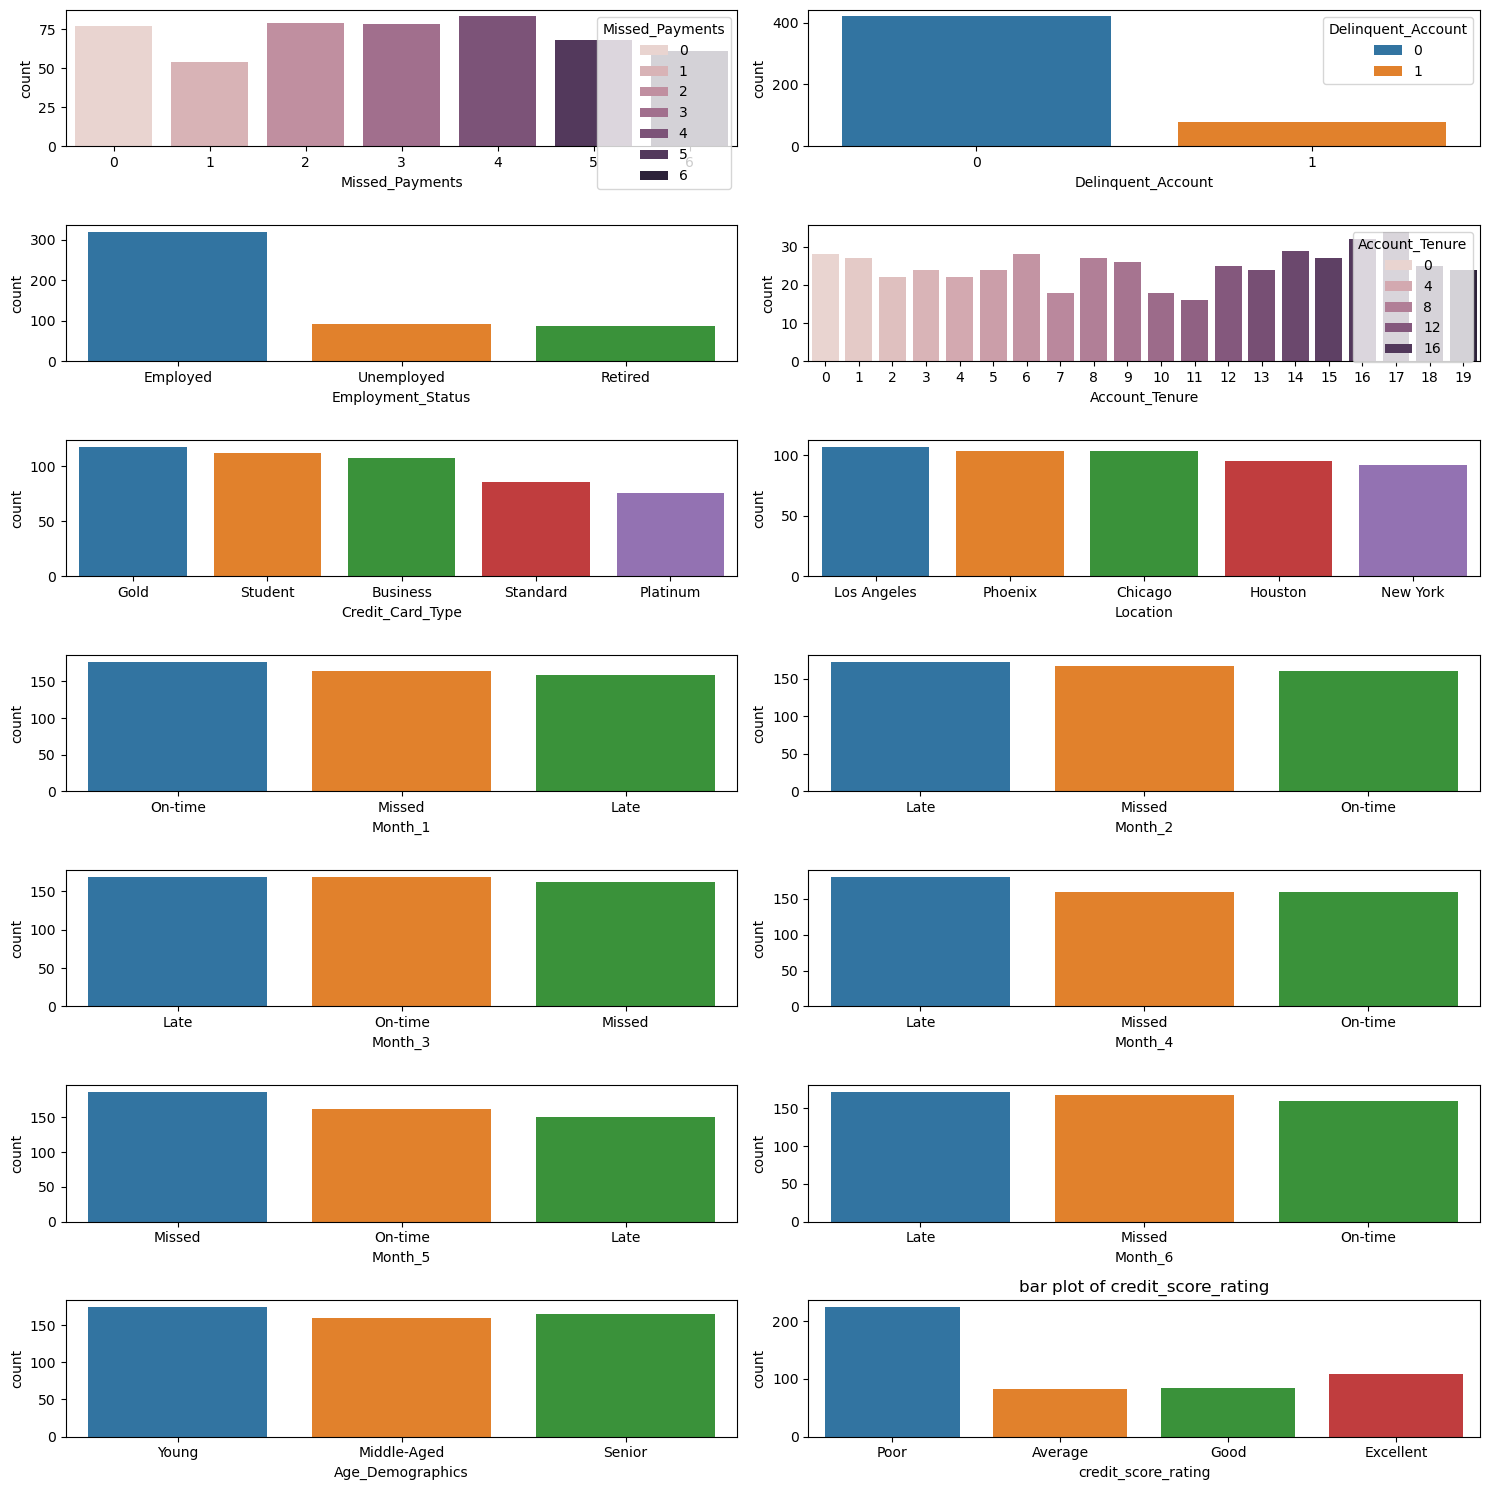

In [36]:
fig,ax = plt.subplots(7,2,figsize = (15,15),)
ax = ax.flatten()
for i,col in enumerate(cat_cols):
    df1 = df[col].value_counts().reset_index()
    sns.barplot(data =df1 , x = col, y = 'count',hue =col,ax =ax[i],)
    plt.title(f'bar plot of {col}')

plt.tight_layout()
plt.show()

# insights
The univariate analysis of categorical variables shows that most customers are employed, indicating that salaried individuals form the largest customer segment in the dataset. Among credit card types, Gold cards are the most common, while Platinum cards have comparatively fewer users. The location distribution appears fairly balanced across cities, although Los Angeles has slightly more customers than other locations. In the age group analysis, customers aged Young  represent the highest population, suggesting middle-aged individuals are the primary customer base. The credit score rating of the customers are majorly poor. The delinquency target variable is imbalanced, with significantly fewer delinquent accounts compared to non-delinquent accounts, which may affect predictive model performance.

## Bivariate analysis (num to num)

<Axes: >

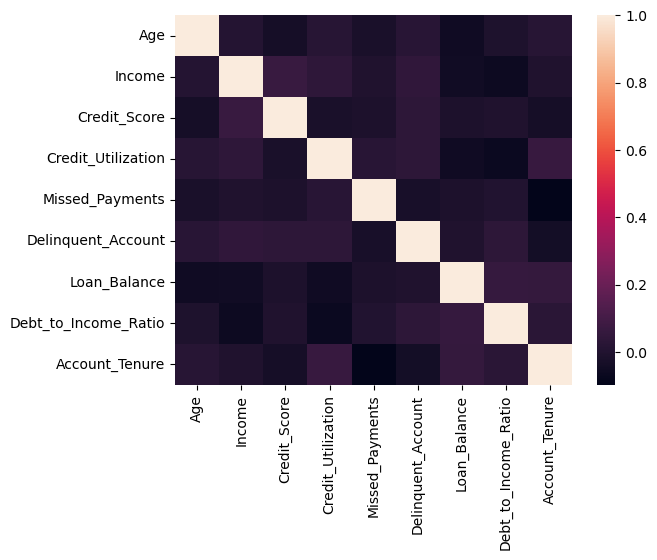

In [37]:
sns.heatmap(df.corr(numeric_only = True))

In [38]:
corr_df = df[num_cols].corr().unstack().reset_index()
corr_df = corr_df[corr_df[0] !=1]


In [39]:
bins = [-1,-0.5,0,0.5,1]
labels = ['strong_negative','weak_negative','weak_positive','strong_positive']
corr_df['corr_status'] = pd.cut(corr_df[0],bins = bins,labels = labels)

In [40]:
corr_df['corr_status'].value_counts()

corr_status
weak_negative      34
weak_positive      22
strong_negative     0
strong_positive     0
Name: count, dtype: int64

<Axes: xlabel='corr_status', ylabel='count'>

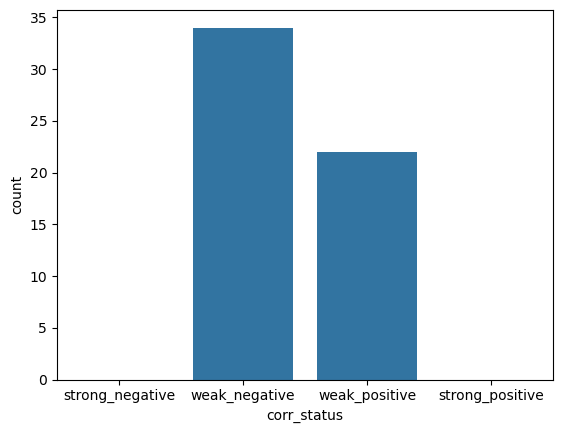

In [41]:
sns.barplot(data =corr_df['corr_status'].value_counts() )

# conclusion
The correlation analysis shows that most numerical variables have weak positive or weak negative relationships with each other, with no strong correlations present in the dataset. This indicates low multicollinearity, meaning the features provide mostly independent information for modeling. The absence of strong correlations suggests that delinquency is influenced by multiple factors rather than a single numerical variable. Weak correlations also indicate that more advanced models may better capture complex relationships in the data.

# bivaraite analysis of cat to cat columns

## – Credit Score Rating vs Delinquent Account


In [42]:
pd.crosstab(df['credit_score_rating'],df['Delinquent_Account'],normalize = 'index').sort_values(1,ascending = False)*100

Delinquent_Account,0,1
credit_score_rating,,
Good,82.142857,17.857143
Excellent,82.407407,17.592593
Poor,84.444444,15.555556
Average,86.746988,13.253012


Customers with credit scores between 650-750 show the highest delinquency percentage, while customers with lower credit score ranges show slightly lower delinquency rates. This indicates that credit score alone may not fully explain delinquency behavior in the dataset. Other financial factors may also influence delinquency risk.

##  Employment Status vs Delinquent Account




In [43]:
pd.crosstab(df['Employment_Status'],df['Delinquent_Account'],normalize = 'index').sort_values(1,ascending = False)*100

Delinquent_Account,0,1
Employment_Status,,
Unemployed,80.645161,19.354839
Employed,83.750000,16.250000
Retired,88.505747,11.494253


Unemployed customers have the highest delinquency percentage compared to other employment groups, indicating higher financial risk. Retired customers show the lowest delinquency rate, suggesting more stable repayment behavior.




##  Age Group vs Delinquent Account

In [44]:
pd.crosstab(df['Age_Demographics'],df['Delinquent_Account'],normalize = 'index').sort_values(1,ascending = False)*100

Delinquent_Account,0,1
Age_Demographics,,
Middle-Aged,82.500000,17.500000
Senior,83.636364,16.363636
Young,85.714286,14.285714


Among age groups, customers middle aged have higher delinquency percentages, while the young  group has the lowest delinquency rate.

## Location vs Delinquent Account



In [45]:
pd.crosstab(df['Location'],df['Delinquent_Account'],normalize = 'index').sort_values(1,ascending = False)*100

Delinquent_Account,0,1
Location,,
Los Angeles,80.373832,19.626168
Houston,83.157895,16.842105
Phoenix,83.495146,16.504854
Chicago,85.436893,14.563107
New York,88.043478,11.956522


Customers from Los Angeles show slightly higher delinquency percentages compared to other locations, while New York has the lowest delinquency rate. 

## Credit Card Type vs Delinquent Account

In [46]:
pd.crosstab(df['Credit_Card_Type'],df['Delinquent_Account'],normalize = 'index').sort_values(1,ascending = False)*100

Delinquent_Account,0,1
Credit_Card_Type,,
Business,78.703704,21.296296
Student,82.142857,17.857143
Gold,85.593220,14.406780
Standard,87.209302,12.790698
Platinum,88.157895,11.842105


Business and Student credit card holders have higher delinquency percentages than Standard and Platinum card holders. Platinum card users appear to have the lowest delinquency risk.

## Account Tenure vs Delinquent Account

In [47]:
pd.crosstab(df['Account_Tenure'],df['Delinquent_Account'],normalize = 'index').sort_values(1,ascending = False).head(10)*100

Delinquent_Account,0,1
Account_Tenure,,
0,71.428571,28.571429
4,72.727273,27.272727
18,76.000000,24.000000
9,76.923077,23.076923
1,77.777778,22.222222
10,77.777778,22.222222
6,78.571429,21.428571
19,79.166667,20.833333
16,81.250000,18.750000


Customers with very low account tenure show higher delinquency percentages compared to long-term customers. This suggests that newer customers may have less stable repayment behavior. Longer account tenure appears to be associated with lower delinquency risk.

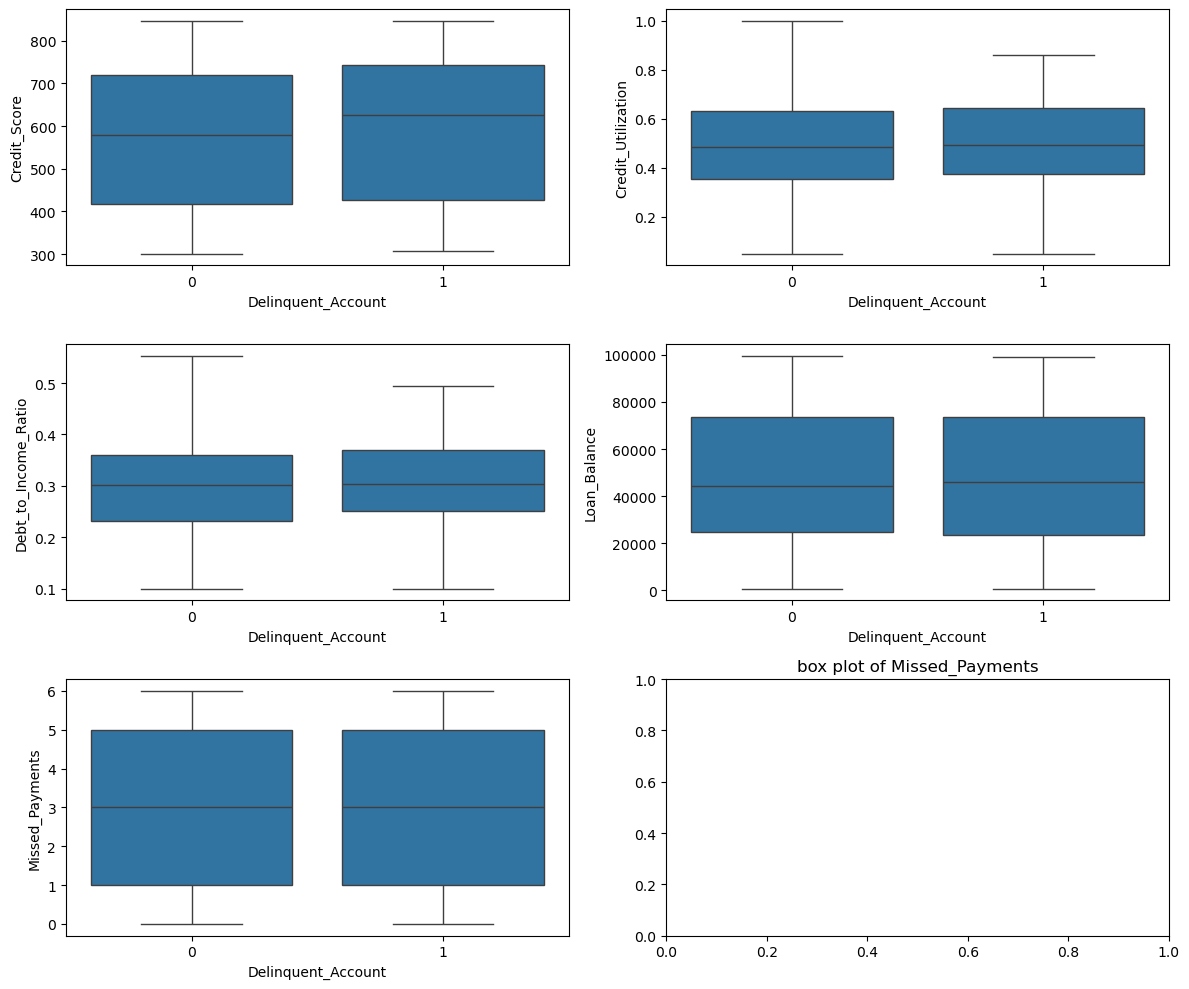

In [48]:
cols = ['Credit_Score','Credit_Utilization','Debt_to_Income_Ratio','Loan_Balance','Missed_Payments']
fig,ax = plt.subplots(3,2,figsize= (12,10))
ax = ax.flatten()
for i,col in enumerate(cols):
    sns.boxplot(data =df, y = col,x  = 'Delinquent_Account',ax = ax[i])
    plt.title(f'box plot of {col}')

plt.tight_layout()
plt.show()




In [49]:
df.groupby('Delinquent_Account')[['Credit_Score','Credit_Utilization','Debt_to_Income_Ratio','Loan_Balance','Missed_Payments']].mean()

,Credit_Score,Credit_Utilization,Debt_to_Income_Ratio,Loan_Balance,Missed_Payments
Delinquent_Account,,,,,
0,575.145238,0.488357,0.297445,48522.854762,2.990476
1,591.150000,0.506887,0.306301,48210.687500,2.850000


The boxplots and groupby analysis show that delinquent customers have slightly higher average credit utilization and debt-to-income ratios compared to non-delinquent customers, indicating greater financial pressure. Loan balances for delinquent customers are also marginally higher, suggesting higher debt exposure may increase delinquency risk. However, credit scores and missed payments do not show major differences between the two groups in this dataset. Overall, delinquency appears to be influenced by multiple financial factors rather than a single strong numerical indicator.

In [50]:
df.groupby(['Employment_Status','Credit_Card_Type'])['Delinquent_Account'].mean().sort_values(ascending = False).reset_index().head()

,Employment_Status,Credit_Card_Type,Delinquent_Account
0,Unemployed,Business,0.333333
1,Retired,Gold,0.263158
2,Unemployed,Student,0.238095
3,Employed,Business,0.205882
4,Employed,Student,0.181818


**Unemployed** customers with **Business** credit cards show the **highest delinquency rate**, indicating **higher financial risk** in this group. **Retired** customers using **Gold** cards also show relatively **high delinquency levels**. Overall, employment status combined with card type appears to influence delinquency behavior.

In [51]:
df.groupby(['credit_score_rating','Age_Demographics'],observed = True)['Delinquent_Account'].mean().sort_values(ascending = False).reset_index().head()

,credit_score_rating,Age_Demographics,Delinquent_Account
0,Good,Middle-Aged,0.333333
1,Excellent,Young,0.212121
2,Excellent,Senior,0.205882
3,Poor,Middle-Aged,0.171429
4,Good,Senior,0.166667


Customers  **Middle-Aged** with very **high credit scores** (650-750) show the **highest delinquency percentage** in the dataset. **Young** with **High credit scores** also show **elevated delinquency rates**. This suggests that credit score alone does not fully determine repayment behavior, and age-related financial patterns may also impact delinquency.

In [52]:
df.groupby(['credit_score_rating','Age_Demographics','Delinquent_Account'],observed = True)[['Credit_Utilization','Debt_to_Income_Ratio']].mean().sort_values(['Credit_Utilization','Debt_to_Income_Ratio'],ascending =[False,False]).reset_index().head()

,credit_score_rating,Age_Demographics,Delinquent_Account,Credit_Utilization,Debt_to_Income_Ratio
0,Average,Young,1,0.759096,0.362500
1,Good,Senior,0,0.571568,0.260084
2,Excellent,Senior,1,0.566870,0.341323
3,Poor,Middle-Aged,1,0.558422,0.287387
4,Average,Middle-Aged,1,0.555111,0.337323


Customers with delinquent accounts generally show higher credit utilization and higher debt-to-income ratios compared to non-delinquent customers. Younger age groups with moderate credit scores appear to have higher financial stress indicators. This indicates that financial burden and credit usage are important contributors to delinquency risk. more than 50% credit uitlization and debt to income ratio more than 0.33 increase the chances of customer to become deliquent

In [53]:
df.groupby(['Account_Tenure'],observed = True)['Delinquent_Account'].mean().sort_values(ascending = False).reset_index().head()

,Account_Tenure,Delinquent_Account
0,0,0.285714
1,4,0.272727
2,18,0.240000
3,9,0.230769
4,1,0.222222


In [54]:
df.groupby(['Location','Delinquent_Account'],observed = True)[['Credit_Utilization','Debt_to_Income_Ratio']].mean().sort_values(['Credit_Utilization','Debt_to_Income_Ratio'],ascending =[False,False]).reset_index().head()

,Location,Delinquent_Account,Credit_Utilization,Debt_to_Income_Ratio
0,New York,1,0.548009,0.315795
1,Phoenix,1,0.526717,0.265659
2,Los Angeles,1,0.513636,0.318697
3,Phoenix,0,0.506447,0.301807
4,Chicago,0,0.504013,0.312664


Customers with lower account tenure show higher delinquency percentages, suggesting newer customers are more likely to default. Among locations, delinquent customers in New York and Phoenix show relatively higher credit utilization levels. Overall, shorter customer history and higher utilization appear associated with greater delinquency risk.

In [55]:
#  any 1 months missed payment deliquency rate

condition = (
    (df['Month_1']=='Missed') |
    (df['Month_2']=='Missed')  |
    (df['Month_3']=='Missed') |
    (df['Month_4']=='Missed')  |
    (df['Month_5']=='Missed') | (df['Month_6']=='Missed')
)

df[condition]['Delinquent_Account'].mean() * 100

np.float64(15.65217391304348)

In [56]:
# continuous any 2 months missed payment deliquency rate

condition = (
    ((df['Month_1']=='Missed') & (df['Month_2']=='Missed')) |
    ((df['Month_2']=='Missed') & (df['Month_3']=='Missed')) |
    ((df['Month_3']=='Missed') & (df['Month_4']=='Missed')) |
    ((df['Month_4']=='Missed') & (df['Month_5']=='Missed')) |
    ((df['Month_5']=='Missed') & (df['Month_6']=='Missed'))
)

df[condition]['Delinquent_Account'].mean() * 100

np.float64(16.582914572864322)

In [57]:
# continuous any 3 months missed payment deliquency rate

condition = (
    ((df['Month_1']=='Missed') & (df['Month_2']=='Missed') & (df['Month_3']=='Missed')) |
    ((df['Month_2']=='Missed') & (df['Month_3']=='Missed') & (df['Month_4']=='Missed')) |
    ((df['Month_3']=='Missed') & (df['Month_4']=='Missed') & (df['Month_5']=='Missed')) |
    ((df['Month_4']=='Missed') & (df['Month_5']=='Missed') & (df['Month_6']=='Missed'))
)

df[condition]['Delinquent_Account'].mean() * 100

np.float64(15.686274509803921)

In [58]:
# continuous any 4 months missed payment deliquency rate
condition = (
    ((df['Month_1']=='Missed') & (df['Month_2']=='Missed') & (df['Month_3']=='Missed') & (df['Month_4']=='Missed')) |
    ((df['Month_2']=='Missed') & (df['Month_3']=='Missed') & (df['Month_4']=='Missed') & (df['Month_5']=='Missed')) |
    ((df['Month_3']=='Missed') & (df['Month_4']=='Missed') & (df['Month_5']=='Missed') & (df['Month_6']=='Missed')) 
   
)

df[condition]['Delinquent_Account'].mean() * 100

np.float64(25.0)

In [59]:
condition = (
    (df['Age_Demographics'] == 'Senior') &
    (df['Credit_Utilization'] > 0.5)
)

df[condition]['Delinquent_Account'].mean()*100

np.float64(13.253012048192772)

In [60]:
condition = (
    (df['Age_Demographics'] == 'Young') &
    (df['Credit_Utilization'] > 0.5)
)

df[condition]['Delinquent_Account'].mean()*100

np.float64(15.789473684210526)

In [61]:
condition = (
    (df['Age_Demographics'] == 'Middle-Aged') &
    (df['Credit_Utilization'] > 0.5)
)

df[condition]['Delinquent_Account'].mean()*100

np.float64(21.052631578947366)

In [62]:
#  creating column on continuous 4 missed payments
condition = (
    ((df['Month_1']=='Missed') & (df['Month_2']=='Missed') & (df['Month_3']=='Missed') & (df['Month_4']=='Missed')) |
    ((df['Month_2']=='Missed') & (df['Month_3']=='Missed') & (df['Month_4']=='Missed') & (df['Month_5']=='Missed')) |
    ((df['Month_3']=='Missed') & (df['Month_4']=='Missed') & (df['Month_5']=='Missed') & (df['Month_6']=='Missed')) 
   
)
df['continuous_4_missed'] = np.where(condition,1,0)



In [63]:
# df.to_csv('cleaned_Delinquency_prediction_dataset.csv',index = False)

- dropping the Customer_ID , Age_Demographics as cust id is not help in  model building. age demographics col is not useful as there is age colun already


In [165]:
model_df = df.copy()

In [166]:
model_df.drop(columns = ['Customer_ID','Age_Demographics'] ,inplace = True)

In [167]:
model_df.columns

Index(['Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Delinquent_Account', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure',
       'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3',
       'Month_4', 'Month_5', 'Month_6', 'credit_score_rating',
       'continuous_4_missed'],
      dtype='object')

# Feature Engineering 

In [168]:
X = model_df[['Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure',
       'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3',
       'Month_4', 'Month_5', 'Month_6', 'credit_score_rating','continuous_4_missed']]
y = model_df[['Delinquent_Account']]


In [187]:
from sklearn.model_selection import train_test_split
# splitting the data in train and test 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state = 42)

- selecting test_size 0.3 as there is imbalance data. the model will not able predict the deliquent customer correctly

- applying ordinal enconder on these columns Month_1 , Month_2 , Month_3,	Month_4,	Month_5	,Month_6	,credit_score_rating to convert in ordinal data
- appply one hot encoder on the cols Employment_Status , Credit_Card_Type , Location
- standardizing he columns Age,Income , Credit_Score,Loan_Balance ,Missed_Payments,  Account_Tenure,  as they  do not dominate in model learning process
-  there is no need of apply Label encoding on deliquent column

In [188]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [189]:
X_train.columns

Index(['Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Loan_Balance', 'Debt_to_Income_Ratio',
       'Employment_Status', 'Account_Tenure', 'Credit_Card_Type', 'Location',
       'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'credit_score_rating', 'continuous_4_missed'],
      dtype='object')

In [190]:
transformer = ColumnTransformer(transformers= [
    ('tnf1',OrdinalEncoder(categories = [['Missed','Late','On-time'],['Missed','Late','On-time'],['Missed','Late','On-time'],['Missed','Late','On-time'],['Missed','Late','On-time'],['Missed','Late','On-time'],['Poor','Average','Good','Excellent']]),['Month_1' , 'Month_2' , 'Month_3',	'Month_4',	'Month_5'	,'Month_6'	,'credit_score_rating']),
    ('tnf2',OneHotEncoder(sparse_output = False,drop = 'first'),['Employment_Status' , 'Credit_Card_Type' , 'Location']),
    ('tnf3',StandardScaler(),[ 'Age','Income' , 'Credit_Score','Loan_Balance' ,'Missed_Payments',  'Account_Tenure'])
],remainder = 'passthrough')

# transforming the data in both train and test data
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed  = transformer.transform(X_test)


In [191]:
# applying smote on the data to to reduce the imbalance in it 
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
X_train_resampled_smote , y_train_resampled_smote =  smote.fit_resample(X_train_transformed,y_train)

# training Logistic Regression

In [192]:
# training the model
lr = LogisticRegression( random_state = 42 )
lr.fit(X_train_resampled_smote,y_train_resampled_smote.values.ravel())

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [193]:
# prediction by the trained model
y_pred = lr.predict(X_test_transformed)

In [194]:
# evaluating the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5466666666666666
              precision    recall  f1-score   support

           0       0.82      0.60      0.69       126
           1       0.12      0.29      0.17        24

    accuracy                           0.55       150
   macro avg       0.47      0.44      0.43       150
weighted avg       0.70      0.55      0.61       150

[[75 51]
 [17  7]]


In [195]:
from sklearn.metrics import roc_auc_score

y_prob = lr.predict_proba(X_test_transformed)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.4031084656084656


- The Logistic Regression model achieved 55% accuracy.
- It performed reasonably well for the majority class (non-delinquent customers)
- but struggled with the minority class (delinquent customers). It identified only 7 out of 18 delinquent customers, resulting in 25% recall and 8% precision for the positive class.
- The ROC-AUC score of 0.407 indicates that the model has poor ability to distinguish between delinquent and non-delinquent customers.
-  Overall, Logistic Regression is not the best model for this dataset, and more advanced models or further tuning should be considered.

In [200]:
feature_names = transformer.get_feature_names_out()

In [201]:
coef = lr.coef_[0]

In [202]:

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

importance = importance.sort_values("Coefficient", ascending=False)
importance.head()

,Feature,Coefficient
24,remainder__Debt_to_Income_Ratio,1.158749
19,tnf3__Credit_Score,1.141964
23,remainder__Credit_Utilization,1.114064
25,remainder__continuous_4_missed,0.759358
16,tnf2__Location_Phoenix,0.683436


The Logistic Regression coefficient analysis shows that `Credit Utilization`, `Debt-to-Income Ratio`, `Continuous 4 Missed Payments`, and `Month 6` are among the strongest positive predictors of customer delinquency. These variables increase the likelihood that a customer will become delinquent. Further investigation is recommended for Credit Score, as its positive coefficient is contrary to the typical expectation and may be influenced by feature encoding or characteristics of this dataset

In [203]:
importance.tail()

,Feature,Coefficient
7,tnf2__Employment_Status_Retired,-0.454950
9,tnf2__Credit_Card_Type_Gold,-0.492270
10,tnf2__Credit_Card_Type_Platinum,-0.695850
6,tnf1__credit_score_rating,-0.981659
11,tnf2__Credit_Card_Type_Standard,-1.128544


The Logistic Regression coefficient analysis shows that Credit Card Type (`Platinum`, `Standard`, and `Gold`),` Credit Score Rating`, and Location (`New York`) are the strongest negative predictors of customer delinquency. These features reduce the likelihood that a customer will become delinquent. Among them, Platinum Credit Card has the strongest negative influence, indicating that Platinum card holders have the lowest risk of delinquency compared to the reference category.